   ... right here I understand fully how does the `ha` block work, but I don't
   understand why do you need 2 `ha` blocks in `fa` per se. Thanks...
---   


   ... A half adder (ha) can only add 2 BITS together. But in a ripple carry
   adder, each bit position needs to add 3 THINGS: $a$, $b$ AND the carry-in 
   from the previous bit. So you need two half adders chained together -- the
   first adds a+b, the second adds that partial result + cin. ...

   ... A HALF ADDER HAS ONLY 2 INPUTS, BUT EACH BIT POSITION IN A RIPPLE CARRY
   ADDER NEEDS TO ADD 3 THINGS (a, b, and the carry-in from the previous bit).
   So you chain two half adders:

   - HA1 adds `a + b` -> gives a partial sum and maybe a carry.
   - HA2 adds `(partial sum) + cin` -> gives the final sum and maybe another
     carry.

   THE OR GATE at the end catches carries from either stage. At most one of them
   can produce a carry at a time (you can verify this in the truth table -- 
   there's no case where both HA1 and HA2 carry simultaneously produce 1...
   actually wait, try the "MAXIMUM: ALL 1S" challenge: when a=1, b=1, cin=1, HA1
   carries because 1+1 overflows, and HA1's sum becomes 0, so HA2 computes 0+1 
   which doesn't carry. The or GATE JUST NEEDS ANY CARRY TO FIRE).

   ...  


---
   Similarly, the wires connecting the two inputs to an adder block would need
   to be interleaved, s.t. the corresponding bits would be connected to the 
   inputs of a full adder `fa` in a ripple carry adder. Subtraction can be
   compared by inverting the second input and by initialising the carry-in of
   the LSB full adder to a constant one. 

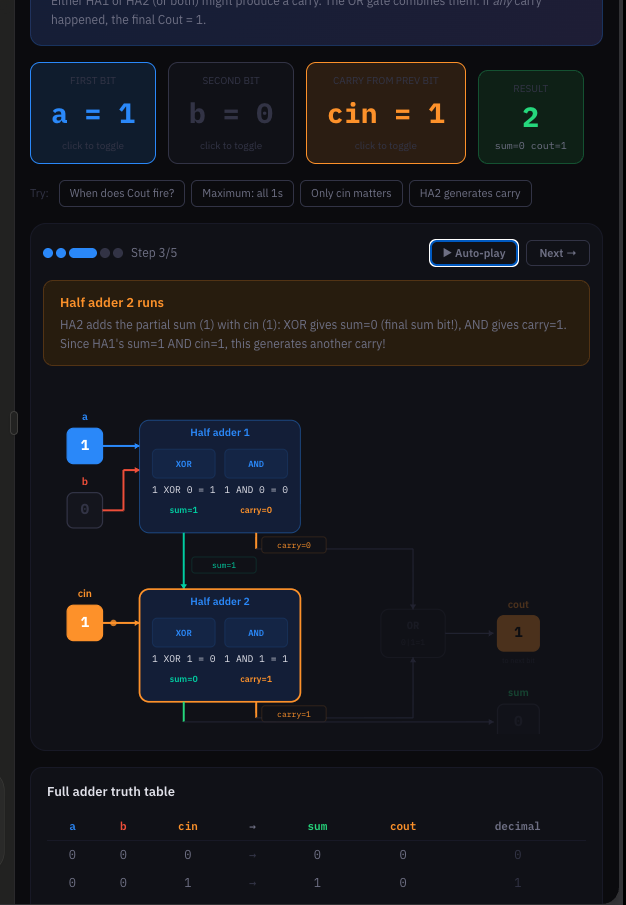

   This is a really elegant optimisation -- it's essentially "loop merging" but
   for hardware. Instead of having separate arrays of AND agtes, OR gates, and
   full adders side by side, you interleave them into one combined unit per bit.
   ...


---
Before (3 arrays)
   Separate AND[0..3], OR[0..3], FA[0..3] arrays. Each bit's `a` and `b` signals
   must fan out to 3 different places. Messy wiring.

-->
STEP 1: AND + OR --> `aor`
   Merge AND[i] and OR[i] into one block. Same `a, b` inputs go to both gates
   locally.

-->
STEP 2: aor + FA --> `afa`
   Merge aor[i] with FA[i]. Now everything for bit i lives in one self-contained
   cell. Stamp out n copies!

-->
AFTER: identical AFA slices (fully merged)
   Each AFA contained one AND gate, one OR agte, and one full adder -- 
   everything one bit needs. Same inputs go in, same results come out.


---
   BENEFIT: Each `afa` is self-contained -- it receives a[i] and b'[i] once,
      computes AND, OR, and sum all locally, and outputs whichever the MUX
      selects. Clean wiring, easy to replicate. Just stamp out 64 of these for a 
      RISC-V ALU!      



---
SOFTWARE ANALOGY: LOOP MERGING

```
Before (3 loops)
for i in 0..3:
  and_out[i] = a[i] & b[i]

for i in 0..3:
  or_out[i] = a[i] | b[i]

for i in 0..3:
  sum[i] = fa(a[i], b[i], c)
```


```
After (1 merged loop)
for i in 0..3:
  // all in one "afa" body
  and_out[i] = a[i] & b[i]
  or_out[i]  = a[i] | b[i]
  sum[i]     = fa(a[i], b[i], c)
  // same inputs, less wiring
```
   
   In software, loop merging reduces memory traffic (fewer reads of a[i] and 
   b[i]). In hardware, interleaving reduces wiring complexity -- each bit's 
   inputs only travel to one local cell instead of fanning out to three
   separate arrays. The interface stays identical: same inputs in, same outs out

---

   In digital logic diagrams, a line with a diagonal slash and a number (like
   `/ 2`) indicates a BUS WIDTH.

   It means the single line actually represents 2 SEPARATE WIRES bundled 
   together for the sake of a cleaner diagram. 

   Here is exactly what those 2 wires are in your screenshot:
      1. THE "AND" RESULT: One wire carries the result of `a[i] AND b[i]`.
      2. THE "OR" RESULT: The other wire carries the result of `a[i] OR b[i]`


WHY IS IT DRAWN LIKE THIS?
   - DECOUPLED PROCESSING: You are correct that it means there are 2 different
     outputs available to process. The hardware computes both simultaneously.
   - THE MUX CONNECTION: These 2 bits (from the `aor` part) and the 1 bit (from
     the `fa` adder part) all eventually feed into a MULTIPLEXER (MUX). The MUX
     uses the `op. select` signal to "decode" or choose which of those wires
     should actually be passed to the final output of the ALU.
   - CLARITY: If the professor drew every single wire for AND, OR, and ADD
     separately for all 64 bits, the diagram would be a "spaghetti" mess. The
     bus notation `/ 2` is just a shorthand way of saying "the AND and OR
     results are both traveling down this path together."  






   In computer architecture, INTERLEAVING is a technique used to increase
   performance, specifically memory throughput and speed, by spreading data or
   memory addresses across multiple independent memory banks. Instead of storing
   sequential data in a single memory module, it is distributed in a round-robin
   fashion, allowing the processor to access multiple modules simultaneously,
   thereby reducing the waiting time (latency) assosciated with memory refresh
   cycles.


KEY ASPECTS OF INTERLEAVING IN COMPUTER ARCHITECTURE
   * MEMORY BANK INTERLEAVING (Low-Order): In this approach, consecutive memory
     addresses are mapped to different memory banks. For example, address 0 goes
     to Bank 0, Address 1 to Bank 1, and so on. This ensures that successive 
     data access is parallelised.
   * PURPOSE: It addresses the "memory bottleneck" or "memory wall" problem, 
     where the CPU operates significantly faster than the memory can supply data
   * PERFORMANCE BENEFITS: It leads to higher throughput and reduced latency for
     memory-intensive applications.   


---

   In the context of computer architecture and ALU design, INTERLEAVING refers 
   to the physical and logical layout where you organise the hardware by BIT
   POSITION rather than by FUNCTION.

   Instead of building a "cluster of 64 AND gates" followed by a "cluster of 64
   Adders," you create a single, self-contained 1-BIT ALU "SLICE" and then 
   repeat that slice $N$ times side-by-side. 

   ...


DETAILED BREAKDOWN OF INTERLEAVING
   When your slide mentions "interleaving," it is describing a transition in how
   we organise the transistors on the chip:

   1. FUNCTIONAL GROUPING (Non-Interleaved):
      * Imagine all the AND gates are in the "North" of the chip, all the OR 
        gates are in the "South", and the Adders are in the "East".
      * THE PROBLEM: If you want to process BIT 0 of your data, the signal for
        $A_0$ and $B_0$ has to travel a long distance to the North (for AND), 
        then a long distance to the South (for OR), and then to the East (for
        ADD). This results in long, messy wires that slows down the processor
        and waste space.
   
   2. BIT-SLICE INTERLEAVING (The Optimisation):
      * We "interleave" the functions. We take 1 AND gate, 1 OR gate, 1 ADDER, 
        and 1 Multiplexer and bundle them together into a single component
        called a `1-Bit ALU SLICE`.
      * THE SOLUTION: Now, the signal for $A_0$ and $B_0$ only has to travel
        ONE PHYSICAL LOCATION on the chip to perform all possible operations.
      * To make a 64-bit ALU, you would simply "stamp out" 64 identical copies
        of this slice and line them up.  


WHY THE TERM "INTERLEAVING"?
   It's called interleaving because we are alternating the types of logic gates
   bit-by-bit. Instead of a solid block of one type of gate, the gates are
   "interleaved" across the silicon ($AND_0, OR_0, ADD_0 -> AND_1, OR_1, ADD_1$)

   IN SHORT: It is the move from building a massive machine that does one thing
   at a time, to building many small, identical "mini-machines" (slices) that 
   each handle one bit of the data completely...        


---

In [ ]:
(\o/)___________________________________________________________(\o/)
(/|\)                                                           (/|\)
  |                                          .-~~~-.              |
  |                                        /        }             |
  |                                       /      .-~              |
  |                             \        |        }               |
  |             __   __       ___\.~~-.-~|     . -~_              |
  |            / \./  \/\_       { O |  ` .-~.    ;  ~-.__        |
  |        __{^\_ _}_   )  }/^\   ~--~/-|_\|   :   : .-~          |
  |       /  /\_/^\._}_/  //  /     /   |  \~ - - ~               |
  |      (  (__{(@)}\__}.//_/__A__/_A___|__A_\___A______A_____A   |
  |       \__/{/(_)\_}  )\\ \\---v-----V----v----v-----V-----v--- |
  |         (   (__)_)_/  )\ \>                                   |
  |          \__/     \__/\/\/                                    |
  |             \__,--'                                           |
  |                                                               |
(\o/)___________________________________________________________(\o/)
(/|\)                                                           (/|\)


---

   ... bring everything together -- the full ALU woith operation selection, and
   the clever SLT (set-less-than) trick. The SLT part is especially neat -- it
   reuses the subtractor to do comparison by feeding the MSB's sign bit back to
   the LSB. 

   

```Python
How SLT works: the MSB-to-LSB trick
   SLT ("set less than") compared SIGNED values: outputs 1 if a < b, else 0. In
   4-bit two's complement, values 8-15 are actually NEGATIVE... 

   The trick: compute a-b using subtract mode. If a < b, then a - b < 0, so the
   MSB (sign bit) = 1.

      SIGNED INTERPRETATION: A = 13 (1101) is actually -3 in signed 4-bit. 
         B = 1 (0001) is actually 1 in signed 4-bit. So we're actually asking:
         is -3 < 1? --> YES
```
                                                        <-- ... wow this is actually absolutely ingenious!
                                                            just rely on a simple quirk of two's complement
                                                            ... and relying on the fact that the subtraction-trick
                                                            work... then EASILY, we can have a simple detector
                                                            for whether is a < b == true!!!
   STEP 1: SUBTRACT
      ALU computes a-b = -3-1 = -4. MSB (bit 3) of subtraction sum =1
   STEP 2: Feed Back to LSB
      MSB's sign bit (1) is wired to bit 0's extra `SLT MUX` input. All other
      bits forced to 0. Result: `0001 = 1` (-3 < 1 is true!)



---      
   OVERFLOW DETECTION -- none
      For signed arithmetic: overflow occurs when adding two positives gives
      positive. Sign(A)=1, Sign(B)=0. Sign(result)=1. Signs are consistent
      -- no overflow.


   SLT is a SIGNED comparison. In 4-bit two's complement, values 8-15 aren't
   what they look like:

   Binary // Unsigned // Signed
   0111 // 7 // +7
   1000 // 8 // -8
   ...

   ...      


---
   After adding `xor` gates as programmable inverters and MULTIPLEXORS for
   selecting the appropriate outputs, we can form our first `ALU` design based
   on `ALUb`, a one-bit ALU element. This design will be managed by two CONTROL
   SIGNALS, $d_0$ and $d_1$, to select one of the four functions to be performed
   by the ALU at run time. Each would correspond to a MIPS instruction. The
   wiring block $L$ is needed to provide the appropriate initialisation to the
   4 left inputs of `ALUb`.



---
COMPARISON OPERATIONS
   * slt: set on less than, if a < b, then 1, else 0
   * if a < b, a-b < 0, so MSB of (a-b) is 1 (64 bits)
   * implementation
      - provide additional input to each cell, left of a_i, b_i
      - LSB input from MSB ALUb output, other inputs set to 0
      - include additional mux in cell for selection
      - to select `slt`, `s=0, d_0=1, d_1=1`

   The new red wire connects the sum output of the rightmost `ALUb'` (the MSB
   of `a-b`) to a new multiplexor which either selects it or the sum output of
   the LSB of ALUb. So the LSB output will be the same as the sum output in the
   MSB for the SLT instruction. This is because if a<b, a-b<0 so the MSB will
   be set, so the output of SLT will be a one as expected. Note that except for
   the LSB, the other ALUb' blocks are initialised by 0 by a new input at the 
   top. This is because the value...



---
   This lecture shows how the ALU, introduced in the last lecture, can be used
   to carry out multiply and divide operations. Interestingly, the two pioneers
   who we shall encounter today were both from London!

   In case you do not know, many great computer scientists worked in London. For
   example ALAN TURING, who was born in London, lived in ... while he worked on
   the design of the ACE (Automatic Computing Engine) at the National Physical
   Laboratory (NPL). He presented a paper on 19 February 1946, which was the
   first detailed design of a stored-program computer.

   Another example is my teacher... who is responsible for many key advances in
   computing including Quicksort, axiomatic semantics, and Communicating 
   Sequential Processes; he won the Turing award in 1980. He worked at Elliot
   Brothers (London) Limited between 1960 and 1968.

   ... these slides wrap up the ALU story nicely -- zero detection for branch
   instructions, why the carry chain is the speed bottleneck, and the clever
   carry--select trick to go faster. ...


---
   Two tabs to explore:


TAB 1: ZERO DETECTION
   This is how `beq` (branch if equal) and `bne` (branch if not equal) work. The
   idea is dead simple: if a = b, then a - b = 0, meaning every single bit of 
   the result is 0. So you just OR all the result bits together and invert -- if
   any bit is 1, the result isn't 0, the zero flag = 1. 

   Try `A=42, B=42` -- every result bit goes green (all zeros), zero flag = 1, 
   so `beq` would take the branch. Now nudge B to 43 -- instantly one bit flips
   red and zero flag drops to 0. That's the entire detection circuit: one big
   NOR gate across all output bits.

   The full control table at the bottom shows all 5 ALU operations with their
   3-bit control codes (`s, d_0, d_1`) -- this is the complete picture from your
   slide.


TAB 2: PERFORMANCE + CARRY SHEET
   Hit "ANIMATE RIPPLE CARRY (slow)" first and watch how each full adder must 
   wait for the previous one's carry. Bit 7 can't even start until bits 0-6 are 
   all done. That's 8 sequential steps -- the critical path. 

   Now hit "ANIMATE CARRY SELECT (fast)" -- notice how the upper half (bits 4-7)
   computes BOTH POSSIBILITIES (cin=0 and cin=1) simultaneously while the lower
   half ripples At t=4, the lower half produces c_4, and the MUX instantly picks
   the correct upper-half result at t=5. No waiting!

   Try A=127, B=129 -- this forces lots of carry propagation. The ripple version
   takes a full 8 steps. The carry select version finishes in ~5 steps because
   the upper half was already done by the time $c_4$ arrived.

   The speed comparison bar at the bottom makes it concrete: carry select is 
   roughly 1.6x faster for 8 bits, at the cost of 50% more hardware (12 FAs
   instead of 8 FAs). For a 64-bit RISC-V processor, you'd split into many more
   blocks and the savings scale even further -- or you'd use a carry-lookahead
   / Brent-Kung adders which achieve $O(log n)$ delay using tree structures.


---
      HOW IT WORKS: The ALU computes a-b. If a=b, then a-b=0, so every bit of 
      the result is 0. A big NOR gate (OR all bits, then invert) checks his in
      one step: if any bit is 1, zero=0; if all bits are 0, zero=1. This 
      single-bit "zero" flag goes straight to the branch control logic. Try
      setting A = B to see zero = 1, then change one of them to see it flip!








---

MODULE COVERAGE
   1. Instructions: format, impact on performance
   2. ALU: architecture, USE IN MULTIPLICATION AND DIVISION...

   ...



---
MULTIPLY AND DIVIDE
   - Implementing multiplication using ALU
   - Booth's multiplication algorithm
   - Implementing division using ALU
   - related RISC-V instructions for multiplication
         ```
         mul         # multiply
         mulh        # multiply high
         multhu      # multiply high unsigned
         multhsu     # multiply high signed unsigned
         ```







---